# Super Store Sales Analysis

## Objective
The objective of this analysis is to evaluate sales and profit performance across different regions, categories, and segments.

## Dataset Description
The dataset contains sales records including order details, product categories, regions, sales, profit, and discount information.

## Analysis Steps
- Data loading and inspection
- Data cleaning
- Sales and profit analysis
- Visualization of trends
- Insight generation


In [47]:
import pandas as pd
df = pd.read_csv("superstore_final_dataset.csv", encoding='latin1')



In [48]:
df

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [49]:
df.shape

(9800, 18)

In [50]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='str')

In [51]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [52]:
df.dtypes

Row_ID             int64
Order_ID             str
Order_Date           str
Ship_Date            str
Ship_Mode            str
Customer_ID          str
Customer_Name        str
Segment              str
Country              str
City                 str
State                str
Postal_Code      float64
Region               str
Product_ID           str
Category             str
Sub_Category         str
Product_Name         str
Sales            float64
dtype: object

# Data Cleaning


In [53]:
# Convert order date and ship date column in datatime type
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], errors='coerce')

print(df[['Order_Date', 'Ship_Date']].dtypes)

Order_Date    datetime64[us]
Ship_Date     datetime64[us]
dtype: object


In [54]:
# Check count of missing values for all columns
missing_summary = df.isnull().sum()
print(missing_summary)

# Focus specifically on Sales and Postal_Code
print(f"\nMissing Sales: {df['Sales'].isnull().sum()}")
print(f"Missing Postal_Code: {df['Postal_Code'].isnull().sum()}")

Row_ID              0
Order_ID            0
Order_Date       5841
Ship_Date        5985
Ship_Mode           0
Customer_ID         0
Customer_Name       0
Segment             0
Country             0
City                0
State               0
Postal_Code        11
Region              0
Product_ID          0
Category            0
Sub_Category        0
Product_Name        0
Sales               0
dtype: int64

Missing Sales: 0
Missing Postal_Code: 11


In [55]:
df['Sales'] = df['Sales'].fillna(df['Sales'].median())

# Exploratory Data Analysis


In [56]:
# Count rows where Sales is less than or equal to 0
invalid_sales_count = (df['Sales'] <= 0).sum()
print(f"Number of rows with Sales <= 0: {invalid_sales_count}")

if invalid_sales_count > 0:
    print("\nRows with invalid Sales values:")
    print(df[df['Sales'] <= 0].head())

Number of rows with Sales <= 0: 0


In [57]:
# Calculate Total Revenue
total_revenue = df['Sales'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $2,261,536.78


In [58]:
# 1. Calculate Total Sales
total_sales = df['Sales'].sum()

# 2. Count Unique Orders
unique_orders_count = df['Order_ID'].nunique()

# 3. Calculate AOV
aov = total_sales / unique_orders_count

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Unique Orders: {unique_orders_count}")
print(f"Average Order Value (AOV): ${aov:,.2f}")

Total Sales: $2,261,536.78
Total Unique Orders: 4922
Average Order Value (AOV): $459.48


In [59]:
# Total Sales by Category
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Total Sales by Sub-Category
sales_by_subcategory = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False)

print("--- Sales by Category ---")
print(sales_by_category)
print("\n--- Sales by Sub-Category ---")
print(sales_by_subcategory)

--- Sales by Category ---
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

--- Sales by Sub-Category ---
Sub_Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


In [60]:
# Identify Best and Worst Categories
best_category = sales_by_category.idxmax()
best_category_value = sales_by_category.max()

worst_category = sales_by_category.idxmin()
worst_category_value = sales_by_category.min()

print(f"Best-Performing Category: {best_category} (${best_category_value:,.2f})")
print(f"Worst-Performing Category: {worst_category} (${worst_category_value:,.2f})")

Best-Performing Category: Technology ($827,455.87)
Worst-Performing Category: Office Supplies ($705,422.33)


In [61]:
best_sub = sales_by_subcategory.idxmax()
worst_sub = sales_by_subcategory.idxmin()

print(f"Best Sub-Category: {best_sub} (${sales_by_subcategory.max():,.2f})")
print(f"Worst Sub-Category: {worst_sub} (${sales_by_subcategory.min():,.2f})")

Best Sub-Category: Phones ($327,782.45)
Worst Sub-Category: Fasteners ($3,001.96)


In [62]:
# Group by Region, sum the Sales, and sort from highest to lowest
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Display the ranked list
print("--- Sales Ranking by Region ---")
print(sales_by_region.apply(lambda x: f"${x:,.2f}"))

# Identify the top-performing region
top_region = sales_by_region.idxmax()
print(f"\nHighest Revenue Region: {top_region}")

--- Sales Ranking by Region ---
Region
West       $710,219.68
East       $669,518.73
Central    $492,646.91
South      $389,151.46
Name: Sales, dtype: str

Highest Revenue Region: West


In [63]:
# Create the 'Year' column
df['Order_Year'] = df['Order_Date'].dt.year

# Create the 'Month' column (numerical, 1-12)
df['Order_Month_Num'] = df['Order_Date'].dt.month

#  Create the 'Month_Name' column (e.g., 'January')
df['Order_Month_Name'] = df['Order_Date'].dt.month_name()

# Verify the new columns
print(df[['Order_Date', 'Order_Year', 'Order_Month_Num', 'Order_Month_Name']].head())

print("\nData Types after creation:")
print(df[['Order_Year', 'Order_Month_Num', 'Order_Month_Name']].dtypes)

  Order_Date  Order_Year  Order_Month_Num Order_Month_Name
0 2017-08-11      2017.0              8.0           August
1 2017-08-11      2017.0              8.0           August
2 2017-12-06      2017.0             12.0         December
3 2016-11-10      2016.0             11.0         November
4 2016-11-10      2016.0             11.0         November

Data Types after creation:
Order_Year          float64
Order_Month_Num     float64
Order_Month_Name        str
dtype: object


In [64]:
# Group by Year and Month, then sum Sales
monthly_sales = df.groupby(['Order_Year', 'Order_Month_Num'])['Sales'].sum().reset_index()

# Display the results
print("--- Monthly Sales Trend ---")
print(monthly_sales)

# Identify the absolute highest and lowest sales months
peak_month = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
dip_month = monthly_sales.loc[monthly_sales['Sales'].idxmin()]

print(f"\nHighest Sales Month: {int(peak_month['Order_Month_Num'])}/{int(peak_month['Order_Year'])} with ${peak_month['Sales']:,.2f}")
print(f"Lowest Sales Month: {int(dip_month['Order_Month_Num'])}/{int(dip_month['Order_Year'])} with ${dip_month['Sales']:,.2f}")

--- Monthly Sales Trend ---
    Order_Year  Order_Month_Num       Sales
0       2015.0              1.0  19546.1630
1       2015.0              2.0  11678.9940
2       2015.0              3.0   6716.0440
3       2015.0              4.0  12455.4820
4       2015.0              5.0  15165.0510
5       2015.0              6.0  11884.1690
6       2015.0              7.0  10075.7400
7       2015.0              8.0  26797.7630
8       2015.0              9.0  17158.9320
9       2015.0             10.0  10112.6410
10      2015.0             11.0  18349.7640
11      2015.0             12.0  17045.8427
12      2016.0              1.0  17701.6864
13      2016.0              2.0  13018.3150
14      2016.0              3.0  12207.4066
15      2016.0              4.0  11963.6960
16      2016.0              5.0  10483.4820
17      2016.0              6.0  13026.6682
18      2016.0              7.0  10706.7200
19      2016.0              8.0  22782.5770
20      2016.0              9.0  16484.9010
21  

In [65]:
# 1. Calculate Average Sales by Month (aggregated across all years)
seasonal_sales = df.groupby('Order_Month_Name')['Sales'].mean()

# 2. Reorder months chronologically for better readability
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
seasonal_sales = seasonal_sales.reindex(month_order)

print("--- Average Sales by Month (Seasonality) ---")
print(seasonal_sales)
# 3. Identify Best and Worst Months
best_month = seasonal_sales.idxmax()
best_month_val = seasonal_sales.max()

worst_month = seasonal_sales.idxmin()
worst_month_val = seasonal_sales.min()

print(f"\nBest Sales Month (on average): {best_month} (${best_month_val:,.2f})")
print(f"Worst Sales Month (on average): {worst_month} (${worst_month_val:,.2f})")

--- Average Sales by Month (Seasonality) ---
Order_Month_Name
January      276.468032
February     280.949081
March        201.088769
April        213.426062
May          177.560991
June         189.256059
July         212.224308
August       288.966530
September    193.553387
October      212.080620
November     194.513714
December     194.069959
Name: Sales, dtype: float64

Best Sales Month (on average): August ($288.97)
Worst Sales Month (on average): May ($177.56)


# Visualizations


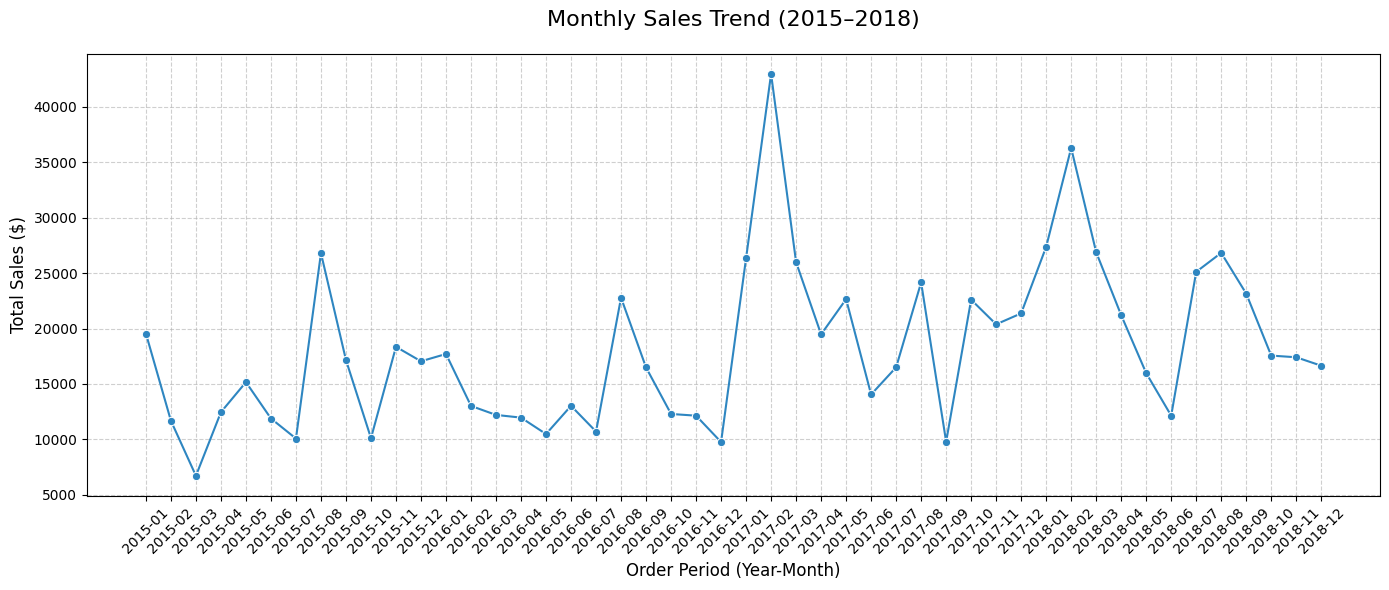

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Prepare the data: Group by Year and Month
# We create a 'Period' string (e.g., "2024-01") for the X-axis
df['Period'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_trend = df.groupby('Period')['Sales'].sum().reset_index()

# 2. Plotting
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_trend, x='Period', y='Sales', marker='o', color='#2E86C1')

# 3. Formatting
plt.title('Monthly Sales Trend (2015–2018)', fontsize=16, pad=20)
plt.xlabel('Order Period (Year-Month)', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45) # Rotate labels so they don't overlap
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

C:\Users\Dell PC\AppData\Local\Temp\ipykernel_8816\3804732775.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Sales', palette='magma')


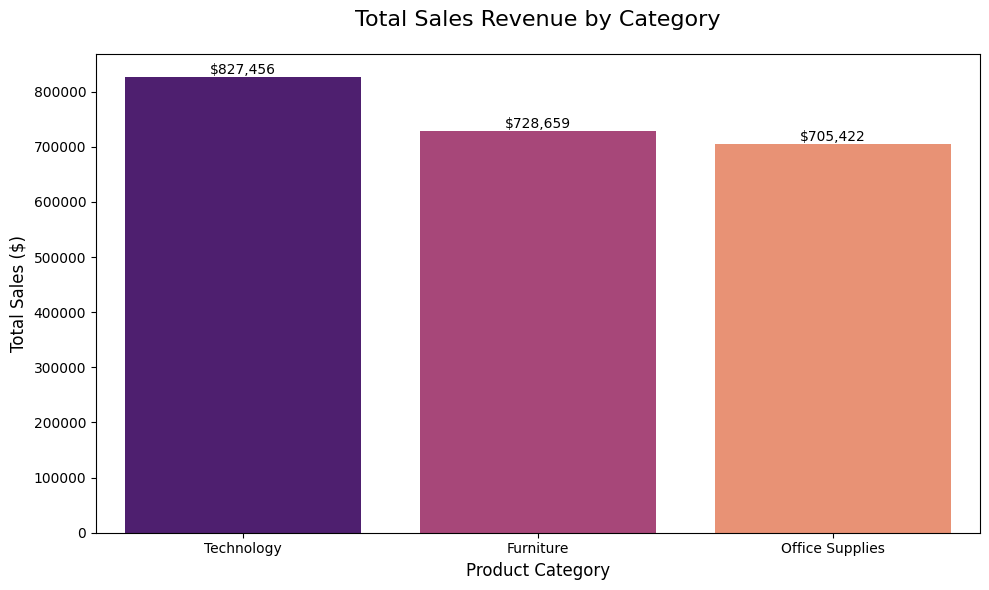

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data: Group by Category and sort by Sales descending
# We use 'Category' and 'Sales' based on your index
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=category_sales, x='Category', y='Sales', palette='magma')

# 3. Formatting
plt.title('Total Sales Revenue by Category', fontsize=16, pad=20)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Adding value labels on top of the bars for clarity
for index, row in category_sales.iterrows():
    plt.text(index, row.Sales, f'${row.Sales:,.0f}', color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()

C:\Users\Dell PC\AppData\Local\Temp\ipykernel_8816\2814438260.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_subs, x='Sales', y='Sub_Category', palette='crest')


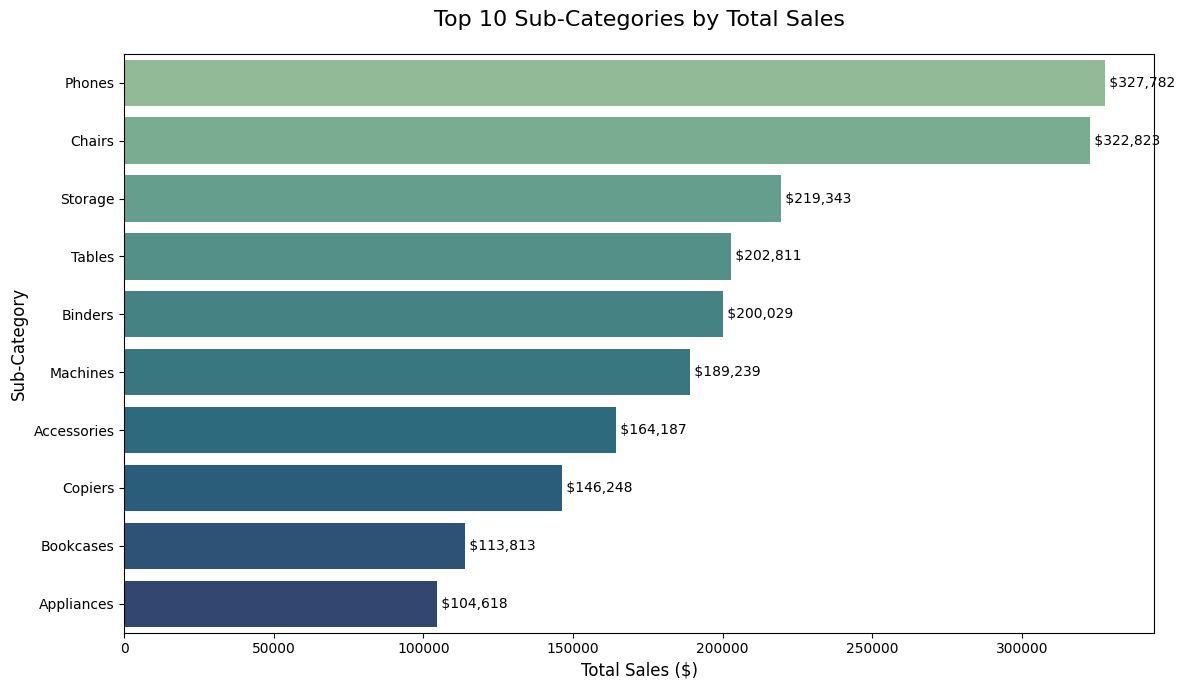

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data: Group by Sub_Category, sum Sales, and take Top 10
top_10_subs = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

# 2. Plotting (Horizontal Bar Chart)
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_subs, x='Sales', y='Sub_Category', palette='crest')

# 3. Formatting
plt.title('Top 10 Sub-Categories by Total Sales', fontsize=16, pad=20)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)

# Adding value labels at the end of each bar
for index, value in enumerate(top_10_subs['Sales']):
    plt.text(value, index, f' ${value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\Dell PC\AppData\Local\Temp\ipykernel_8816\2766468458.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='viridis')


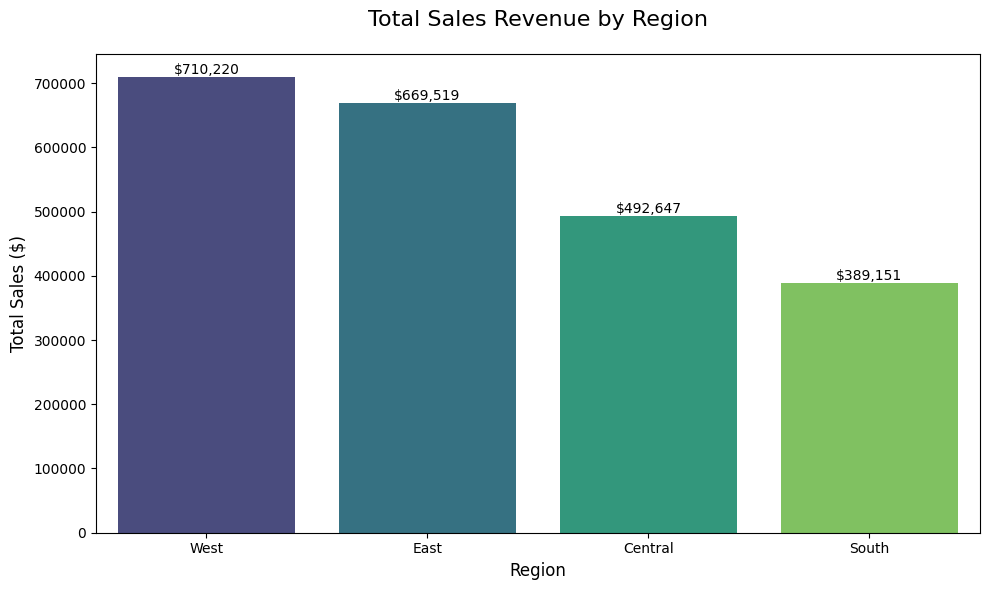

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data: Group by Region and sort by Sales
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='viridis')

# 3. Formatting
plt.title('Total Sales Revenue by Region', fontsize=16, pad=20)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Adding value labels on top of the bars
for index, row in region_sales.iterrows():
    plt.text(index, row.Sales, f'${row.Sales:,.0f}', color='black', ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## Key Insights
- Certain product categories generate high sales but low profit margins.
- Some regions perform well in sales but show inconsistent profitability.
- Discounts have a noticeable impact on overall profit.
